In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

np.random.seed(1)

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

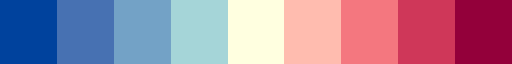

In [3]:
my_cmap



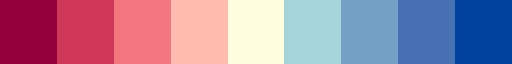

In [4]:
my_cmap_r


In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *





########################################################
########################################################
# Fig 5-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path="Data/test"):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

In [39]:
not os.path.isfile(session_name+'/Data_Assymetricity.xlsx')

False

In [14]:
session_name="Data/TwoVar_U_S_dependency"
if not os.path.exists(session_name):

   # Create a new directory because it does not exist
   os.makedirs(session_name)
   print("The new directory is created!")


###################
######################################
#########################################################

N_simul=1
S=12
u_list=np.arange(0,1.5,0.1)
N_u=len(u_list)
s_list=np.arange(5,51,5)
N_s=len(s_list)
o=0
t=[0,5000]

threshold=1e-3

###################
######################################
#########################################################
Intention_to_reset=False
if Intention_to_reset or not os.path.isfile(session_name+'/Data_Assymetricity.xlsx'):
    Data_Assymetricity=np.zeros((len(u_list),len(s_list), N_simul))
    for i,u in enumerate(u_list):
        for j,s in enumerate(s_list):
            for itt in range(N_simul):
                ###########
                np.random.seed(itt)
                f_interaction=lambda : uniform_distribution(u,o)
                num_C=2
                num_S=s
                N=num_C*num_S
                I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

                CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

                y=np.random.rand(N)*0.1
                y1=run_lotka_volterra(y, t, CommunitiesLibrary[0,:], I, g, k)
                y2=run_lotka_volterra(y, t, CommunitiesLibrary[1,:], I, g, k)

                y1[y1<threshold]=0
                y2[y2<threshold]=0
                y3=np.array(y1+y2)
                survived=y3>threshold
                y3=run_lotka_volterra(y3, t, survived, I, g, k)
                y3[y3<threshold]=0
                Similarity_to1 =(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))

                Assimilarity_BC=abs(2* Similarity_to1-1)
                Data_Assymetricity[i,j, itt]=Assimilarity_BC
                #########
    
    Data_Assymetricity=Data_Assymetricity.reshape(N_u*N_s,-1)
    df1=pd.DataFrame(Data_Assymetricity)
    with pd.ExcelWriter(session_name+'/Data_Assymetricity.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')

In [49]:
Data_Assymetricity.reshape(3*9,-1)

array([[4.17860981e-04],
       [1.29256137e-06],
       [3.19594598e-04],
       [3.96642427e-04],
       [2.19871895e-06],
       [5.70401730e-04],
       [3.99840675e-04],
       [1.06522946e-04],
       [8.51886619e-04],
       [3.08691051e-01],
       [4.14663263e-01],
       [2.93701477e-01],
       [2.32945240e-02],
       [1.30884186e-01],
       [6.85079565e-01],
       [9.99999979e-01],
       [8.07329264e-01],
       [8.44144103e-01],
       [8.40692976e-02],
       [1.88724654e-01],
       [6.87563542e-01],
       [9.91124686e-01],
       [1.00000000e+00],
       [4.77572970e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00]])

In [13]:
np.arange(5,51,5)

array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])

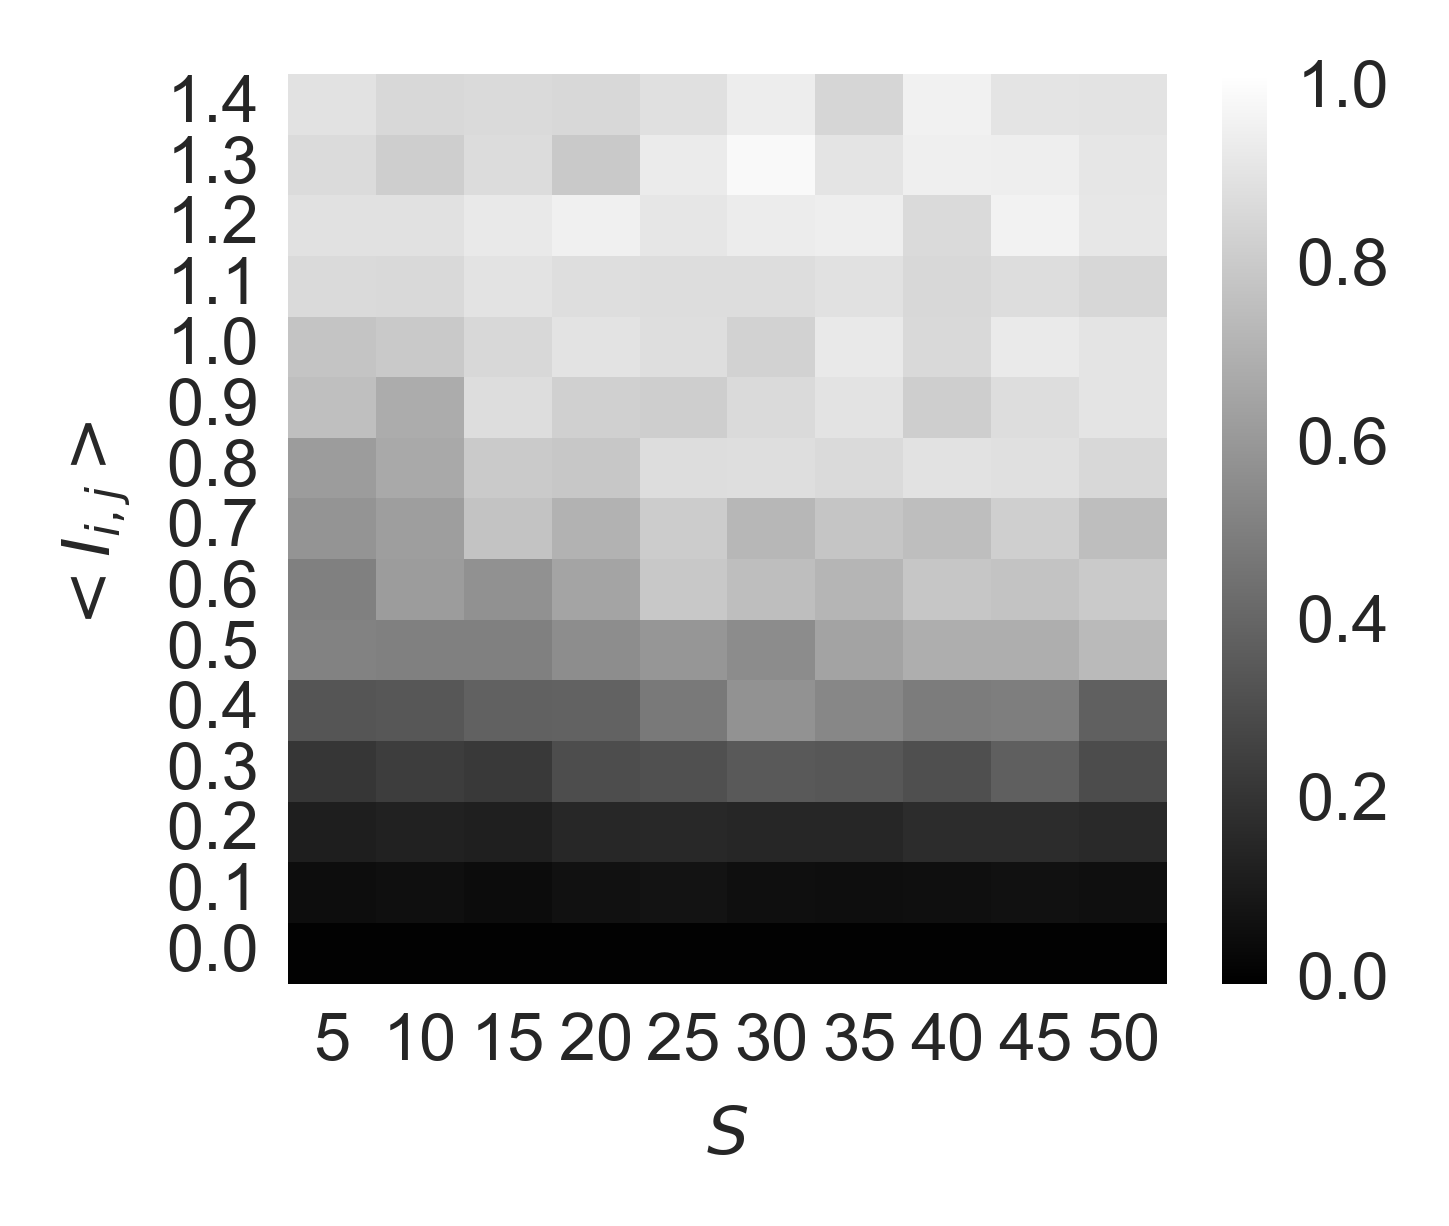

In [18]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx')
df = df.values[0:,1:]
df = df.reshape(N_u,N_s,-1)

f, ax = plt.subplots(1, figsize=(60*mm,50*mm), facecolor='w', edgecolor='k')


data = np.mean(df,2)
x_labels = s_list
y_labels = u_list
sns.heatmap(data, annot=False, cmap='gist_gray', vmin=-0.01, vmax=1.01, xticklabels=x_labels, yticklabels=y_labels)
#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')


# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
plt.xlabel('$S$')
plt.ylabel('$<I_{i,j}>$')
ax.invert_yaxis()
ax.set_xticklabels(FormatStrFormatter('%d').format_ticks(x_labels))
ax.set_yticklabels(FormatStrFormatter('%.1f').format_ticks(y_labels))

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-3_TwoVar_S_U_dependency_heatmap_Assymetry_mean.svg', bbox_inches='tight')


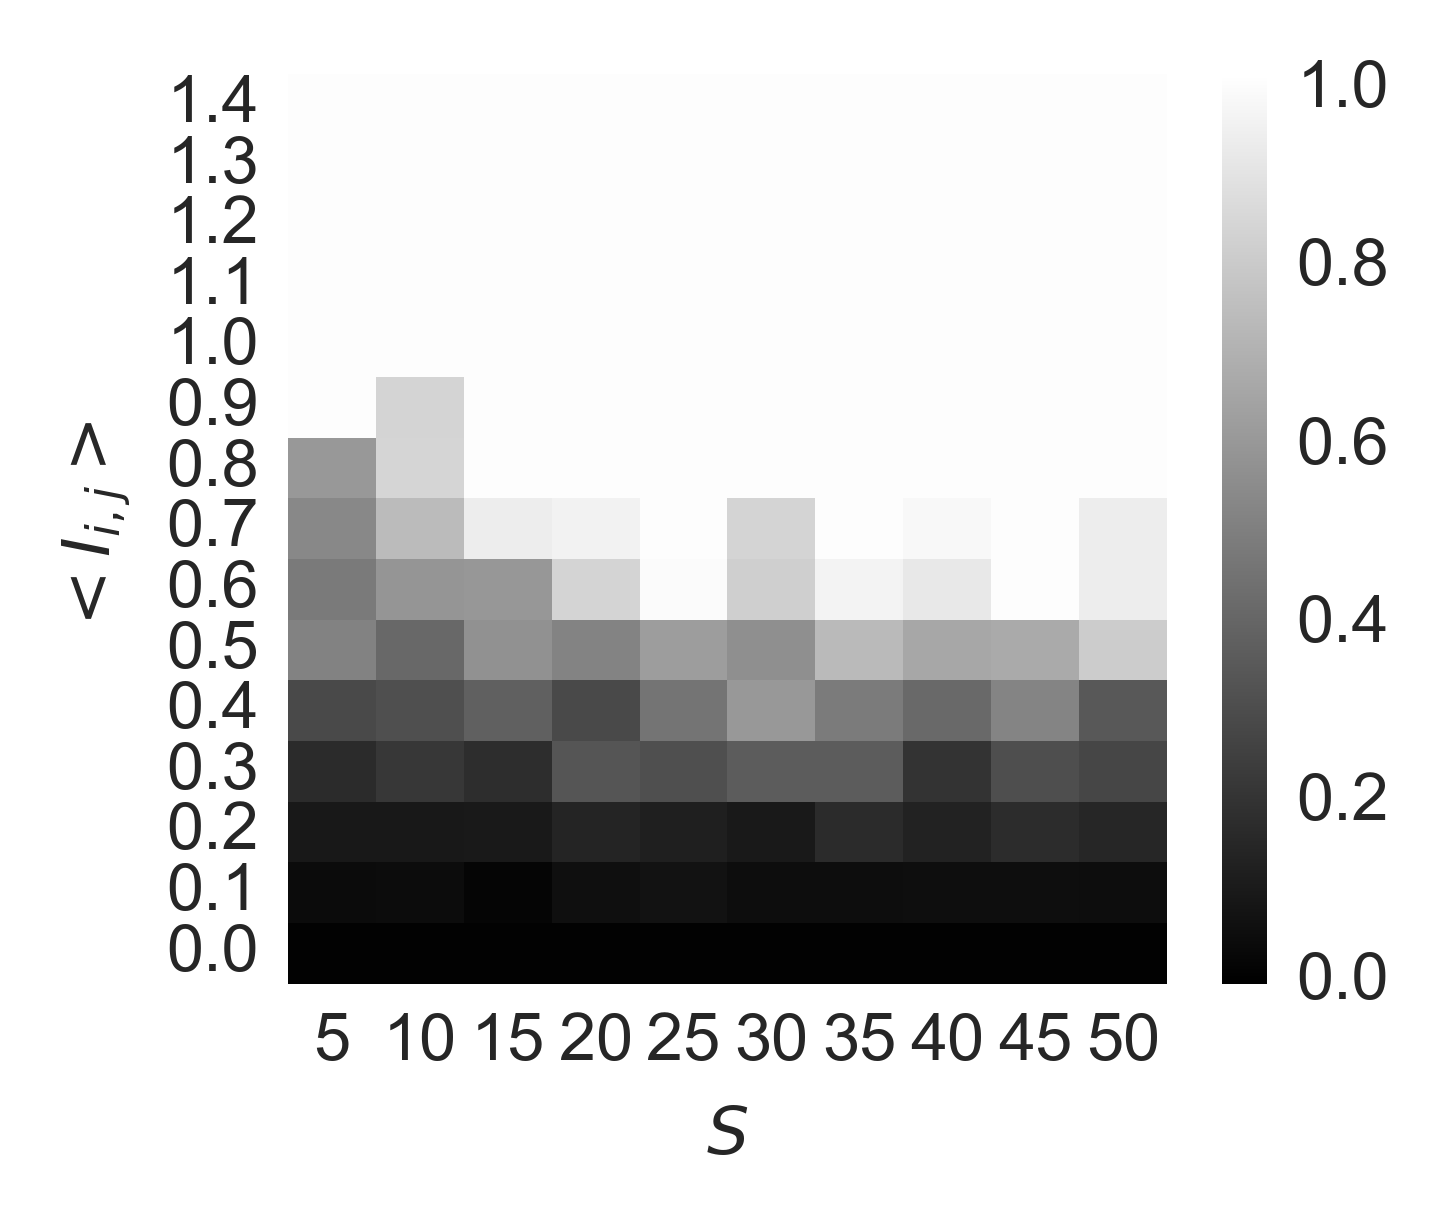

In [19]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx')
df = df.values[0:,1:]
df = df.reshape(N_u,N_s,-1)

f, ax = plt.subplots(1, figsize=(60*mm,50*mm), facecolor='w', edgecolor='k')


data = np.median(df,2)
x_labels = s_list
y_labels = u_list
sns.heatmap(data, annot=False, cmap='gist_gray', vmin=-0.01, vmax=1.01, xticklabels=x_labels, yticklabels=y_labels)
#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')


# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
plt.xlabel('$S$')
plt.ylabel('$<I_{i,j}>$')
ax.invert_yaxis()
ax.set_xticklabels(FormatStrFormatter('%d').format_ticks(x_labels))
ax.set_yticklabels(FormatStrFormatter('%.1f').format_ticks(y_labels))

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-3_TwoVar_S_U_dependency_heatmap_Assymetry_median.svg', bbox_inches='tight')


In [ ]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value